In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

In [3]:
dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Beeswarm/beeswarm.xlsx"
total = pd.read_excel(dataset_total_path, sheet_name="Sample")

subclass = "Limonoids"
level = 'Third'

df = total.set_index('Class')
mask = df.loc[level] == subclass
df = df.loc[:, mask]
df = df.reset_index()
df.head()

df = df.iloc[3:]
df.head()

KeyError: 'Class'

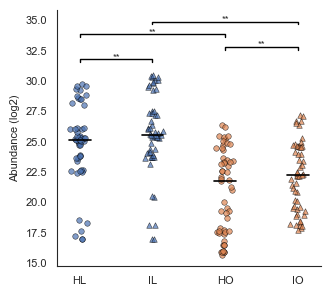

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# LOAD DATA
# ==================================================
dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Beeswarm/beeswarm.xlsx"
total = pd.read_excel(dataset_total_path, sheet_name="Sample")

subclass = "Limonoids"
level = "Third"

df = total.set_index("Class")
mask = df.loc[level] == subclass
df = df.loc[:, mask]
df = df.reset_index()

df = df.iloc[3:]  # remove annotation rows

# ==================================================
# WIDE → LONG FORMAT
# ==================================================
df_long = df.melt(
    id_vars="Class",
    var_name="Metabolite",
    value_name="Abundance"
)

# Harmonize class names
class_map = {
    "Lemon control": "HL",
    "Lemon HLB": "IL",
    "Orange control": "HO",
    "Orange HLB": "IO"
}

df_long["Class"] = df_long["Class"].map(class_map)

# ==================================================
# GLOBAL STYLE
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
sns.set_style("white")

# ==================================================
# FIGURE
# ==================================================
fig, ax = plt.subplots(figsize=(3.35, 3.0))

color_map = {
    "HL": "#4c73b2",
    "IL": "#4c73b2",
    "HO": "#de8552",
    "IO": "#de8552"
}

marker_map = {
    "HL": "o",
    "IL": "^",
    "HO": "o",
    "IO": "^"
}

order = ["HL", "IL", "HO", "IO"]

for i, cls in enumerate(order):
    subset = df_long[df_long["Class"] == cls]

    x_positions = np.random.normal(
        loc=i,
        scale=0.05,
        size=len(subset)
    )

    ax.scatter(
        x_positions,
        subset["Abundance"],
        color=color_map[cls],
        marker=marker_map[cls],
        s=16,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.4
    )

    median = subset["Abundance"].median()

    ax.plot(
        [i - 0.15, i + 0.15],
        [median, median],
        color="black",
        linewidth=1.2
    )

# ==================================================
# AXES
# ==================================================
ax.set_xticks(range(4))
ax.set_xticklabels(order)
ax.set_ylabel("Abundance (log2)")
ax.set_xlabel("")

# ==================================================
# SIGNIFICANCE BARS
# ==================================================

comparisons = [
    ("HL", "IL", "**"),
    ("HO", "IO", "**"),
    ("HL", "HO", "**"),
    ("IL", "IO", "**")
    
]

order_index = {name: i for i, name in enumerate(order)}

y_max = df_long["Abundance"].max()
y_range = df_long["Abundance"].max() - df_long["Abundance"].min()

bar_spacing = y_range * 0.07   # espace entre les barres
bar_height = y_range * 0.015   # hauteur des crochets
text_offset = y_range * 0.005  # distance texte-barre

for i, (g1, g2, label) in enumerate(comparisons):

    x1 = order_index[g1]
    x2 = order_index[g2]

    y = y_max + bar_spacing * (i + 1)

    ax.plot(
        [x1, x1, x2, x2],
        [y, y + bar_height, y + bar_height, y],
        lw=1,
        color="black"
    )

    ax.text(
        (x1 + x2) * 0.5,
        y + bar_height * 0.00015,
        label,
        ha='center',
        va='bottom',
        fontsize=7
    )

sns.despine()
plt.tight_layout()

# ==================================================
# EXPORT
# ==================================================
plt.savefig(f"C:/Users/tamer/Documents/PhD/ML/Beeswarm/{subclass}_abundance.pdf",
            bbox_inches="tight")
plt.savefig(f"C:/Users/tamer/Documents/PhD/ML/Beeswarm/{subclass}_abundance.tif",
            dpi=600,
            bbox_inches="tight",
           format='tiff')

plt.show()

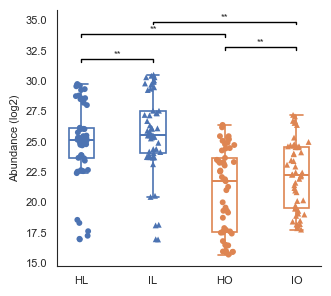

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# LOAD DATA
# ==================================================
dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Beeswarm/beeswarm.xlsx"
total = pd.read_excel(dataset_total_path, sheet_name="Sample")

subclass = "Limonoids"
level = "Third"

df = total.set_index("Class")
mask = df.loc[level] == subclass
df = df.loc[:, mask]
df = df.reset_index()

df = df.iloc[3:]

# ==================================================
# WIDE → LONG FORMAT
# ==================================================
df_long = df.melt(
    id_vars="Class",
    var_name="Metabolite",
    value_name="Abundance"
)

class_map = {
    "Lemon control": "HL",
    "Lemon HLB": "IL",
    "Orange control": "HO",
    "Orange HLB": "IO"
}

df_long["Class"] = df_long["Class"].map(class_map)

# ==================================================
# GLOBAL STYLE
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

sns.set_style("white")

# ==================================================
# FIGURE
# ==================================================
fig, ax = plt.subplots(figsize=(3.35, 3.0))

color_map = {
    "HL": "#4c73b2",
    "IL": "#4c73b2",
    "HO": "#de8552",
    "IO": "#de8552"
}

marker_map = {
    "HL": "o",
    "IL": "^",
    "HO": "o",
    "IO": "^"
}

order = ["HL", "IL", "HO", "IO"]

# ==================================================
# BOXPLOT (transparent)
# ==================================================
for cls in order:

    subset = df_long[df_long["Class"] == cls]

    sns.boxplot(
        x="Class",
        y="Abundance",
        data=subset,
        order=order,
        width=0.35,
        showfliers=False,
        boxprops=dict(
            facecolor="none",
            edgecolor=color_map[cls],
            linewidth=1.2
        ),
        whiskerprops=dict(
            color=color_map[cls],
            linewidth=1.2
        ),
        capprops=dict(
            color=color_map[cls],
            linewidth=1.2
        ),
        medianprops=dict(
            color=color_map[cls],
            linewidth=1.4
        ),
        ax=ax
    )

# ==================================================
# SCATTER POINTS (no transparency)
# ==================================================
for i, cls in enumerate(order):

    subset = df_long[df_long["Class"] == cls]

    x_positions = np.random.normal(
        loc=i,
        scale=0.05,
        size=len(subset)
    )

    ax.scatter(
        x_positions,
        subset["Abundance"],
        color=color_map[cls],
        marker=marker_map[cls],
        s=18,
        alpha=1,
        edgecolor="none"
    )

# ==================================================
# AXES
# ==================================================
ax.set_xticks(range(4))
ax.set_xticklabels(order)

ax.set_ylabel("Abundance (log2)")
ax.set_xlabel("")

# ==================================================
# SIGNIFICANCE BARS
# ==================================================
comparisons = [
    ("HL", "IL", "**"),
    ("HO", "IO", "**"),
    ("HL", "HO", "**"),
    ("IL", "IO", "**")
]

order_index = {name: i for i, name in enumerate(order)}

y_max = df_long["Abundance"].max()
y_range = y_max - df_long["Abundance"].min()

bar_spacing = y_range * 0.07
bar_height = y_range * 0.015

for i, (g1, g2, label) in enumerate(comparisons):

    x1 = order_index[g1]
    x2 = order_index[g2]

    y = y_max + bar_spacing * (i + 1)

    ax.plot(
        [x1, x1, x2, x2],
        [y, y + bar_height, y + bar_height, y],
        lw=1,
        color="black"
    )

    ax.text(
        (x1 + x2) * 0.5,
        y + bar_height,
        label,
        ha='center',
        va='bottom',
        fontsize=7
    )

sns.despine()
plt.tight_layout()

# ==================================================
# EXPORT
# ==================================================
plt.savefig(
    f"C:/Users/tamer/Documents/PhD/ML/Beeswarm/{subclass}_abundance_boxplot_2.pdf",
    bbox_inches="tight"
)

plt.savefig(
    f"C:/Users/tamer/Documents/PhD/ML/Beeswarm/{subclass}_abundance_boxplot_2.tif",
    dpi=600,
    bbox_inches="tight",
    format="tiff"
)

plt.show()

C:\Users\tamer\AppData\Local\Temp\ipykernel_16500\1264637740.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\tamer\AppData\Local\Temp\ipykernel_16500\1264637740.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\tamer\AppData\Local\Temp\ipykernel_16500\1264637740.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\tamer\AppData\Local\Temp\ipykernel_16500\1264637740.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

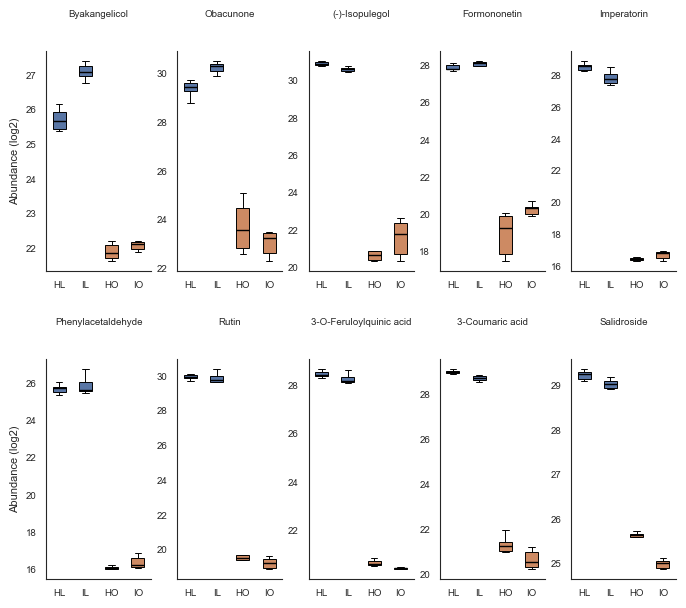

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# LOAD DATA
# ==================================================
dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Beeswarm/beeswarm.xlsx"
df = pd.read_excel(dataset_total_path, sheet_name="candidates")

# clean column names
df.columns = df.columns.str.strip()

# ==================================================
# TRANSFORM TO LONG FORMAT
# ==================================================
df_long = df.melt(
    id_vars="Class",
    var_name="Metabolite",
    value_name="Abundance"
)

# log2 transform
df_long["Abundance"] = np.log2(df_long["Abundance"] + 1)

# ==================================================
# CLASS MAPPING
# ==================================================
class_map = {
    "Lemon control": "HL",
    "Lemon HLB": "IL",
    "Orange control": "HO",
    "Orange HLB": "IO"
}

df_long["Class"] = df_long["Class"].map(class_map)

# ==================================================
# STYLE
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

sns.set_style("white")

color_map = {
    "HL": "#4c73b2",
    "IL": "#4c73b2",
    "HO": "#de8552",
    "IO": "#de8552"
}

order = ["HL", "IL", "HO", "IO"]

# ==================================================
# MULTI-PANEL FIGURE
# ==================================================
metabolites = df_long["Metabolite"].unique()

n_cols = 5
n_rows = int(np.ceil(len(metabolites) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7.0, 3.0 * n_rows),
    sharey=False
)

axes = axes.flatten()

# ==================================================
# LOOP
# ==================================================
for idx, met in enumerate(metabolites):

    ax = axes[idx]
    sub_df = df_long[df_long["Metabolite"] == met]

    # BOXPLOT
    sns.boxplot(
        x="Class",
        y="Abundance",
        data=sub_df,
        order=order,
        width=0.5,
        showfliers=False,
        palette=[color_map[c] for c in order],
        boxprops=dict(edgecolor="black", linewidth=0.7),
        whiskerprops=dict(color="black", linewidth=0.7),
        capprops=dict(color="black", linewidth=0.7),
        medianprops=dict(color="black", linewidth=1.0),
        ax=ax
    )

    # AXES
    ax.set_xticks(range(4))
    ax.set_xticklabels(order, fontsize=7)

    ax.set_title(met, fontsize=7, pad=1, y=1.15)

    ax.set_xlabel("")

    # 👉 LABEL uniquement 1er et 6e plot
    if idx in [0, 5]:
        ax.set_ylabel("Abundance (log2)")
    else:
        ax.set_ylabel("")

    sns.despine(ax=ax)

# ==================================================
# REMOVE EMPTY PANELS
# ==================================================
for j in range(len(metabolites), len(axes)):
    fig.delaxes(axes[j])

# ==================================================
# LAYOUT
# ==================================================
fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.96,
    bottom=0.08,
    wspace=0.25,
    hspace=0.4
)

# ==================================================
# EXPORT
# ==================================================
plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/Beeswarm/all_metabolites_panel.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/Beeswarm/all_metabolites_panel.tif",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

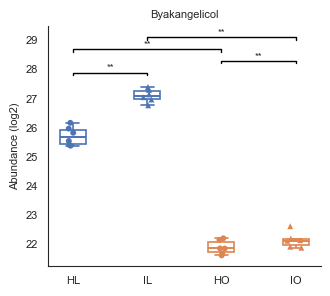

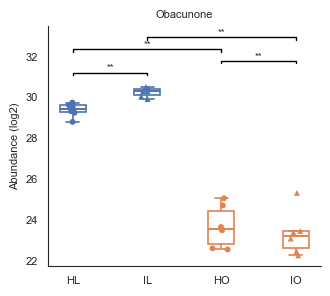

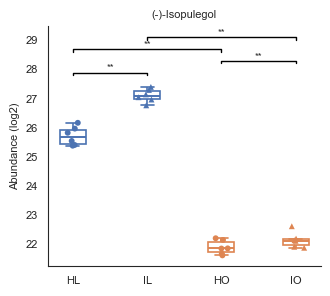

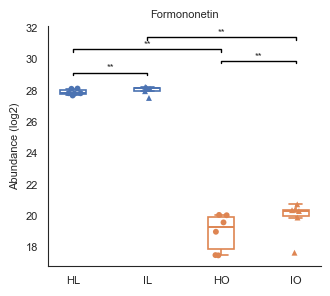

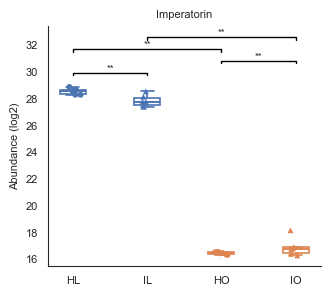

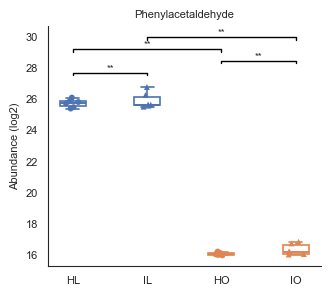

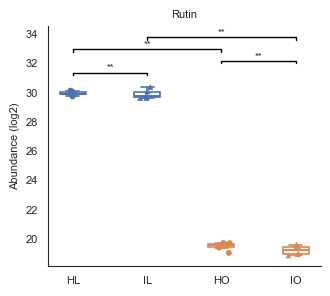

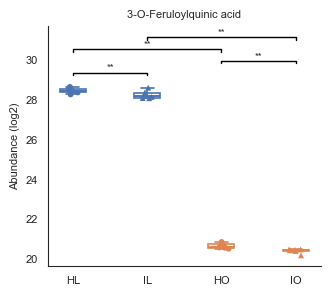

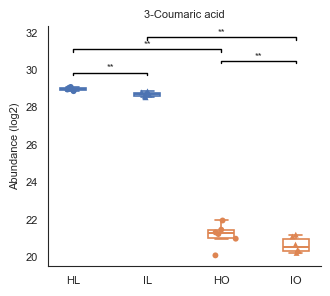

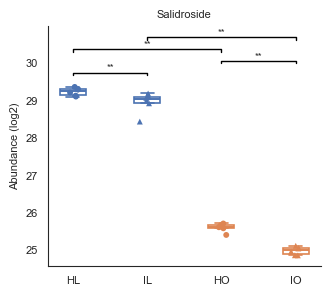

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# LOAD DATA (ADAPTE A TON NOUVEAU DATASET)
# ==================================================
file_path = "C:/Users/tamer/Documents/PhD/ML/Beeswarm/beeswarm.xlsx"
df = pd.read_excel(file_path, sheet_name="candidates")

df.columns = df.columns.str.strip()

# ==================================================
# WIDE → LONG
# ==================================================
df_long = df.melt(
    id_vars="Class",
    var_name="Metabolite",
    value_name="Abundance"
)

# log2 transform
df_long["Abundance"] = np.log2(df_long["Abundance"] + 1)

# ==================================================
# CLASS MAPPING
# ==================================================
class_map = {
    "Lemon control": "HL",
    "Lemon HLB": "IL",
    "Orange control": "HO",
    "Orange HLB": "IO"
}

df_long["Class"] = df_long["Class"].map(class_map)

# remove NA (important)
df_long = df_long.dropna(subset=["Class", "Abundance"])

# ==================================================
# STYLE
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

sns.set_style("white")

color_map = {
    "HL": "#4c73b2",
    "IL": "#4c73b2",
    "HO": "#de8552",
    "IO": "#de8552"
}

marker_map = {
    "HL": "o",
    "IL": "^",
    "HO": "o",
    "IO": "^"
}

order = ["HL", "IL", "HO", "IO"]
order_index = {name: i for i, name in enumerate(order)}

# ==================================================
# LOOP → 1 FIGURE PAR METABOLITE
# ==================================================
metabolites = df_long["Metabolite"].unique()

for met in metabolites:

    sub_df = df_long[df_long["Metabolite"] == met]

    fig, ax = plt.subplots(figsize=(3.35, 3.0))

    # ==================================================
    # BOXPLOT (TON STYLE EXACT)
    # ==================================================
    for cls in order:

        subset = sub_df[sub_df["Class"] == cls]

        if len(subset) == 0:
            continue  # évite crash si classe absente

        sns.boxplot(
            x="Class",
            y="Abundance",
            data=subset,
            order=order,
            width=0.35,
            showfliers=False,
            boxprops=dict(
                facecolor="none",
                edgecolor=color_map[cls],
                linewidth=1.2
            ),
            whiskerprops=dict(
                color=color_map[cls],
                linewidth=1.2
            ),
            capprops=dict(
                color=color_map[cls],
                linewidth=1.2
            ),
            medianprops=dict(
                color=color_map[cls],
                linewidth=1.4
            ),
            ax=ax
        )

    # ==================================================
    # SCATTER (triangles + ronds)
    # ==================================================
    for i, cls in enumerate(order):

        subset = sub_df[sub_df["Class"] == cls]

        if len(subset) == 0:
            continue

        x_positions = np.random.normal(
            loc=i,
            scale=0.05,
            size=len(subset)
        )

        ax.scatter(
            x_positions,
            subset["Abundance"],
            color=color_map[cls],
            marker=marker_map[cls],
            s=18,
            alpha=1,
            edgecolor="none"
        )

    # ==================================================
    # AXES
    # ==================================================
    ax.set_xticks(range(4))
    ax.set_xticklabels(order)

    ax.set_ylabel("Abundance (log2)")
    ax.set_xlabel("")
    ax.set_title(met, fontsize=8, pad=6)

    # ==================================================
    # SIGNIFICANCE (OPTIONNEL / STATIC)
    # ==================================================
    comparisons = [
        ("HL", "IL", "**"),
        ("HO", "IO", "**"),
        ("HL", "HO", "**"),
        ("IL", "IO", "**")
    ]

    y_max = sub_df["Abundance"].max()
    y_range = y_max - sub_df["Abundance"].min()

    bar_spacing = y_range * 0.07
    bar_height = y_range * 0.015

    for i, (g1, g2, label) in enumerate(comparisons):

        x1 = order_index[g1]
        x2 = order_index[g2]

        y = y_max + bar_spacing * (i + 1)

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + bar_height, y + bar_height, y],
            lw=1,
            color="black"
        )

        ax.text(
            (x1 + x2) * 0.5,
            y + bar_height,
            label,
            ha='center',
            va='bottom',
            fontsize=7
        )

    # ==================================================
    # FINAL STYLE
    # ==================================================
    sns.despine()
    plt.tight_layout()

    safe_name = met.replace(" ", "_").replace("/", "_")

    # ==================================================
    # EXPORT
    # ==================================================
    plt.savefig(
        f"C:/Users/tamer/Documents/PhD/ML/Beeswarm/secondaires/{safe_name}.pdf",
        bbox_inches="tight"
    )

    plt.savefig(
        f"C:/Users/tamer/Documents/PhD/ML/Beeswarm/secondaires/{safe_name}.tif",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()